<a href="https://colab.research.google.com/github/evggazarova/lidar-2d-mapping/blob/main/lidar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Загружено 2981 строк
Количество сканов: 11


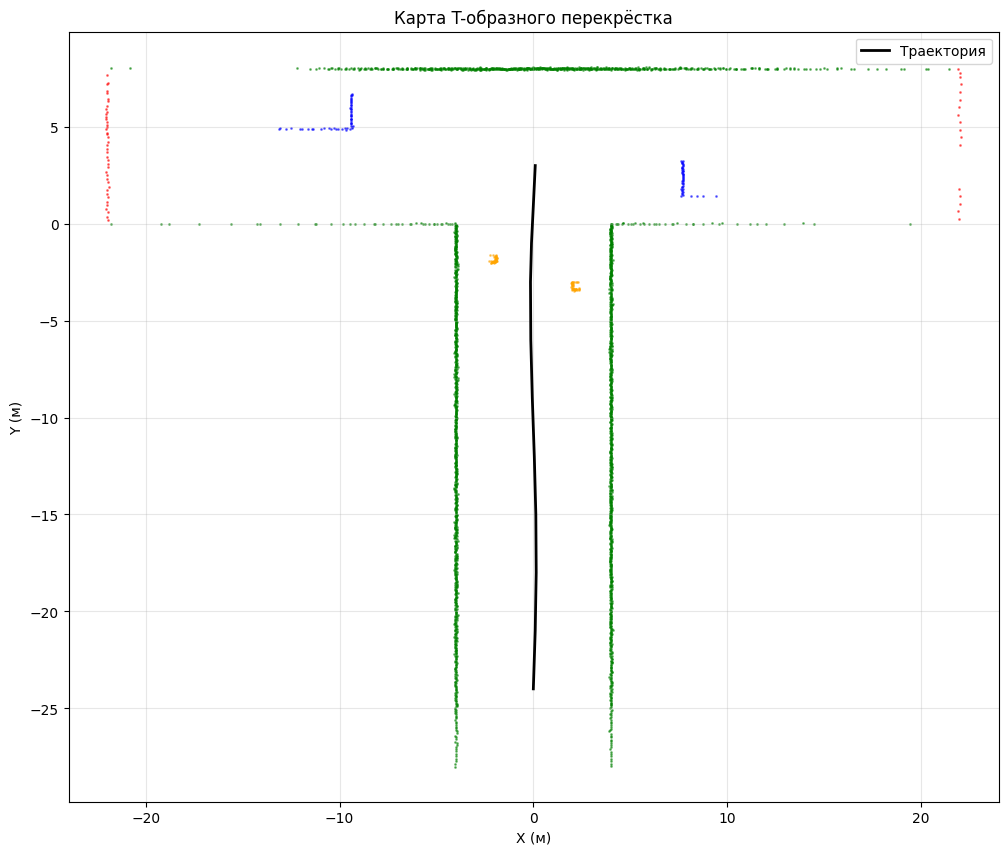

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json

# Просто читаем файлы по названию
df = pd.read_csv('2d_lidar.csv')
with open('2d_lidar_metadata.json', 'r') as f:
    metadata = json.load(f)

print(f"Загружено {len(df)} строк")
print(f"Количество сканов: {df['scan_id'].nunique()}")

# Фильтруем валидные точки
valid = df[df['valid'] == 1]

# Рисуем карту
plt.figure(figsize=(12, 10))

# Цвета для объектов
color_map = {'curb': 'green', 'wall': 'red', 'vehicle': 'blue', 'sign': 'orange'}

for obj, color in color_map.items():
    points = valid[valid['hit_type'] == obj]
    if len(points) > 0:
        plt.scatter(points['hit_x_m'], points['hit_y_m'], c=color, s=1, alpha=0.5)

# Траектория робота
traj = df.groupby('scan_id')[['robot_x_m', 'robot_y_m']].first()
plt.plot(traj['robot_x_m'], traj['robot_y_m'], 'k-', linewidth=2, label='Траектория')

plt.xlabel('X (м)')
plt.ylabel('Y (м)')
plt.title('Карта T-образного перекрёстка')
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

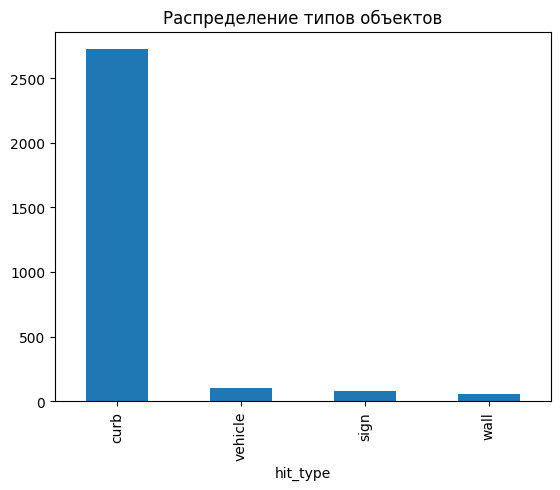

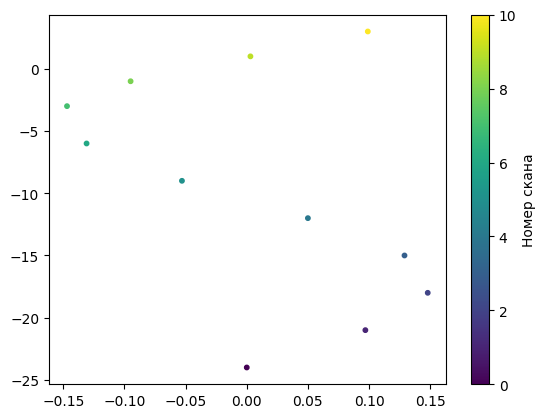

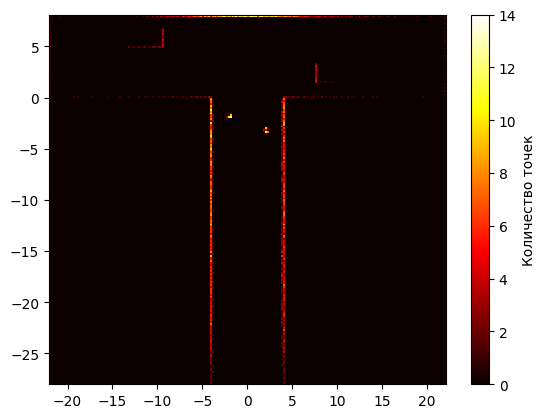

In [ ]:
# 1. Гистограмма распределения объектов
valid['hit_type'].value_counts().plot(kind='bar')
plt.title('Распределение типов объектов')
plt.show()

# 2. Траектория с цветовой кодировкой по времени
plt.scatter(traj['robot_x_m'], traj['robot_y_m'],
           c=range(len(traj)), cmap='viridis', s=10)
plt.colorbar(label='Номер скана')
plt.show()

# 3. Плотность точек на карте
plt.hist2d(valid['hit_x_m'], valid['hit_y_m'], bins=200, cmap='hot')
plt.colorbar(label='Количество точек')
plt.show()